In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)
from sklearn.inspection import permutation_importance

In [5]:
DATA_PATH = "cmpt496features1.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nClass counts:")
print(df["class"].value_counts())

df.head()

Dataset shape: (203769, 37)

Class counts:
class
3    157205
2     42019
1      4545
Name: count, dtype: int64


,txId,Time step,input_count,output_count,input_total,output_total,fee,input_prior_tx_count,input_prior_tx_avg,input_prior_tx_max,...,in_BTC_max,in_BTC_mean,in_BTC_median,in_BTC_total,out_BTC_min,out_BTC_max,out_BTC_mean,out_BTC_median,out_BTC_total,class
0,3321,1,1.0,2.0,0.534072,0.533972,0.0001,0.0,0.0,0.0,...,0.534072,0.534072,0.534072,0.534072,1.668990e-01,0.367074,0.266986,0.266986,0.533972,3
1,11108,1,1.0,2.0,5.611878,5.611778,0.0001,0.0,0.0,0.0,...,5.611878,5.611878,5.611878,5.611878,5.861940e-01,5.025584,2.805889,2.805889,5.611778,3
2,51816,1,1.0,2.0,0.456608,0.456508,0.0001,0.0,0.0,0.0,...,0.456608,0.456608,0.456608,0.456608,2.279902e-01,0.228518,0.228254,0.228254,0.456508,3
3,68869,1,1.0,2.0,9.308900,9.308800,0.0001,0.0,0.0,0.0,...,8.000000,3.102967,1.000000,9.308900,1.229000e+00,8.079800,4.654400,4.654400,9.308800,2
4,89273,1,1.0,13107.0,852.164680,852.164680,0.0000,0.0,0.0,0.0,...,852.164680,852.164680,852.164680,852.164680,1.300000e-07,41.264036,0.065016,0.000441,852.164680,2


In [6]:
known_df = df[df["class"].isin([1, 2])].copy()
unknown_df = df[df["class"] == 3].copy()

print("Known transactions:", len(known_df))
print("Unknown transactions:", len(unknown_df))

print("\nKnown class distribution:")
print(known_df["class"].value_counts())

Known transactions: 46564
Unknown transactions: 157205

Known class distribution:
class
2    42019
1     4545
Name: count, dtype: int64


In [7]:
# 1 = illicit
# 0 = licit

known_df["is_illicit"] = (known_df["class"] == 1).astype(int)

print(known_df["is_illicit"].value_counts())

is_illicit
0    42019
1     4545
Name: count, dtype: int64


In [8]:
missing = known_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Columns with missing values:")
print(missing)

print("\nRows containing at least one missing value:")
print(known_df.isnull().any(axis=1).sum())

Columns with missing values:
input_count       519
output_count      519
input_total       519
output_total      519
fee               519
in_BTC_min        519
in_BTC_max        519
in_BTC_mean       519
in_BTC_median     519
in_BTC_total      519
out_BTC_min       519
out_BTC_max       519
out_BTC_mean      519
out_BTC_median    519
out_BTC_total     519
dtype: int64

Rows containing at least one missing value:
519


In [9]:
drop_columns = [
    "txId",
    "class",
    "is_illicit"
]

feature_columns = [
    col for col in known_df.columns
    if col not in drop_columns
]

print("Number of features:", len(feature_columns))
print("\nFeatures:")
for feature in feature_columns:
    print(feature)

Number of features: 35

Features:
Time step
input_count
output_count
input_total
output_total
fee
input_prior_tx_count
input_prior_tx_avg
input_prior_tx_max
output_prior_tx_count
output_prior_tx_avg
output_prior_tx_max
output_btc_sent
output_btc_sent_avg
output_btc_sent_min
output_btc_sent_max
output_btc_received
output_btc_received_avg
output_btc_received_min
output_btc_received_max
fraction_address_pairs_seen_before
input_btc_sent
input_btc_avg
input_btc_min
input_btc_max
in_BTC_min
in_BTC_max
in_BTC_mean
in_BTC_median
in_BTC_total
out_BTC_min
out_BTC_max
out_BTC_mean
out_BTC_median
out_BTC_total


In [10]:
print("Minimum time step:", known_df["Time step"].min())
print("Maximum time step:", known_df["Time step"].max())

Minimum time step: 1
Maximum time step: 49


# using first 80% of the time steps for training 

In [13]:
split_time = 39

train_df = known_df[known_df["Time step"] <= split_time].copy()
test_df = known_df[known_df["Time step"] > split_time].copy()

print("Training transactions:", len(train_df))
print("Testing transactions:", len(test_df))

print("\nTraining labels:")
print(train_df["is_illicit"].value_counts())

print("\nTesting labels:")
print(test_df["is_illicit"].value_counts())

Training transactions: 35380
Testing transactions: 11184

Training labels:
is_illicit
0    31471
1     3909
Name: count, dtype: int64

Testing labels:
is_illicit
0    10548
1      636
Name: count, dtype: int64


# X and Y values defined 

In [14]:
X_train = train_df[feature_columns].copy()
X_test = test_df[feature_columns].copy()

y_train = train_df["is_illicit"].copy()
y_test = test_df["is_illicit"].copy()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (35380, 35)
X_test: (11184, 35)
y_train: (35380,)
y_test: (11184,)


# Handling missing values 

In [15]:
imputer = SimpleImputer(strategy="median")

X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Missing training values:",
      X_train_imputed.isnull().sum().sum())

print("Missing testing values:",
      X_test_imputed.isnull().sum().sum())

Missing training values: 0
Missing testing values: 0


# Random Forest 

In [16]:
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_imputed, y_train)

print("Random Forest training complete.")

Random Forest training complete.


# Making predictions 

In [17]:
y_pred = rf.predict(X_test_imputed)

# Probability that each transaction is illicit
y_prob = rf.predict_proba(X_test_imputed)[:, 1]

print("Predictions complete.")

Predictions complete.


# Eval of random of forest 

In [18]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Licit", "Illicit"]
    )
)

Accuracy: 0.9584227467811158

Classification Report:
              precision    recall  f1-score   support

       Licit       0.97      0.99      0.98     10548
     Illicit       0.68      0.50      0.58       636

    accuracy                           0.96     11184
   macro avg       0.83      0.74      0.78     11184
weighted avg       0.95      0.96      0.96     11184



# accuracy score = 0.958 (very good) 
# Confusion matrix: 
# Q1 = TN
# Q2 = FP
# Q3 = FN
# Q4 = TP 

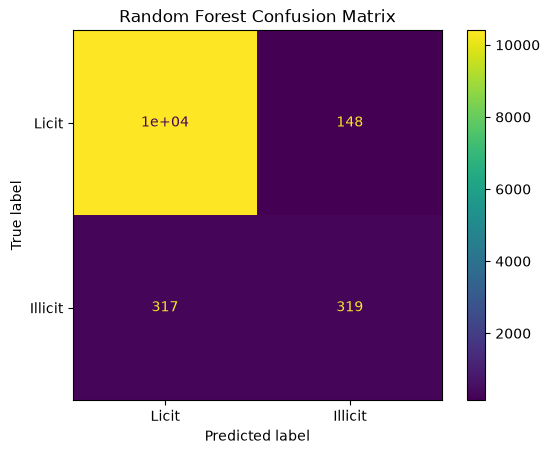

In [19]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Licit", "Illicit"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

# ROC curve 

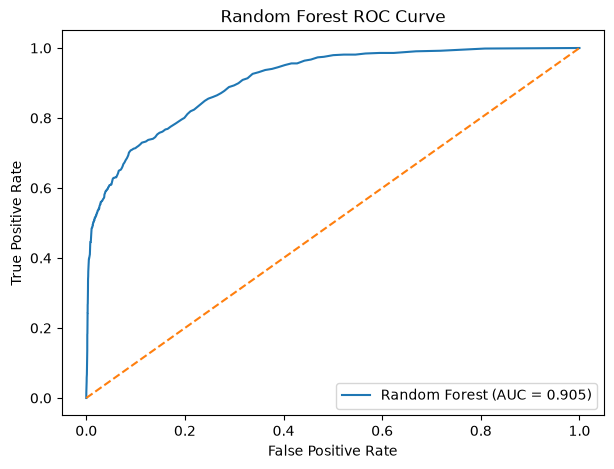

In [20]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {roc_auc:.3f})"
)

plt.plot([0, 1], [0, 1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()

plt.show()

# precision recall curve 

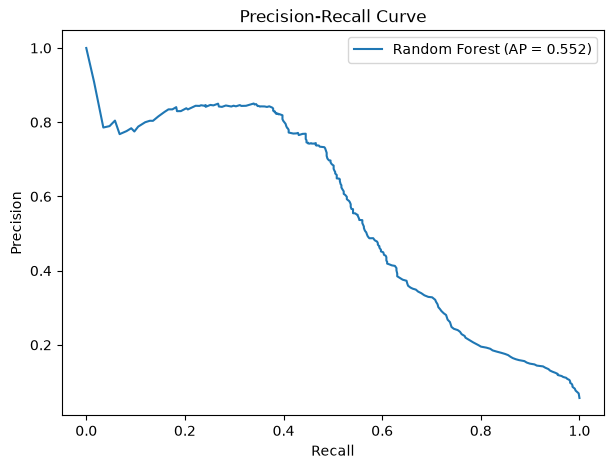

In [21]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

pr_auc = average_precision_score(
    y_test,
    y_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    recall,
    precision,
    label=f"Random Forest (AP = {pr_auc:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.show()

# feuture importance - for our main 3 fraud types 

In [22]:
feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
2,output_count,0.154490
5,fee,0.121973
1,input_count,0.085507
30,out_BTC_min,0.059846
0,Time step,0.052160
25,in_BTC_min,0.048730
19,output_btc_received_max,0.034845
15,output_btc_sent_max,0.033961
17,output_btc_received_avg,0.030962
13,output_btc_sent_avg,0.025173


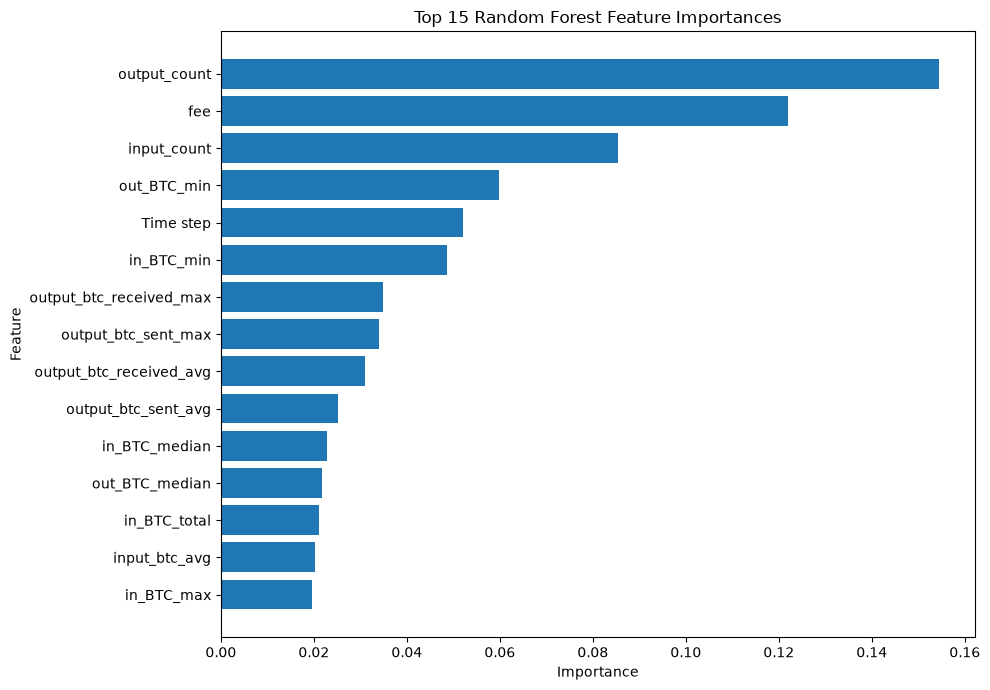

In [23]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")

plt.tight_layout()
plt.show()

# Permutation importance 

In [24]:
perm = permutation_importance(
    rf,
    X_test_imputed,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="average_precision",
    n_jobs=-1
)

perm_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": perm.importances_mean
})

perm_importance = perm_importance.sort_values(
    "Importance",
    ascending=False
)

perm_importance.head(15)

,Feature,Importance
2,output_count,0.312309
30,out_BTC_min,0.056190
1,input_count,0.046889
15,output_btc_sent_max,0.014203
7,input_prior_tx_avg,0.012729
5,fee,0.010728
29,in_BTC_total,0.009849
17,output_btc_received_avg,0.008439
6,input_prior_tx_count,0.006749
13,output_btc_sent_avg,0.006319


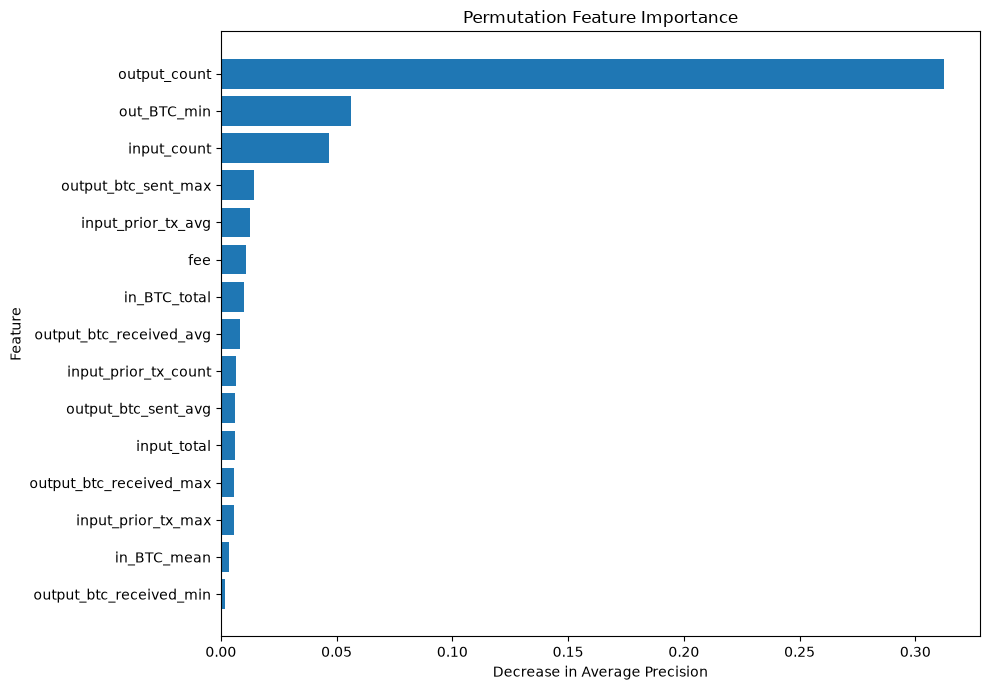

In [25]:
top_perm = perm_importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_perm["Feature"][::-1],
    top_perm["Importance"][::-1]
)

plt.xlabel("Decrease in Average Precision")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance")

plt.tight_layout()
plt.show()

# analyzing illicit (scam) behaviour 

In [26]:
illicit_df = known_df[
    known_df["is_illicit"] == 1
].copy()

licit_df = known_df[
    known_df["is_illicit"] == 0
].copy()

print("Illicit transactions:", len(illicit_df))
print("Licit transactions:", len(licit_df))

Illicit transactions: 4545
Licit transactions: 42019


In [ ]:
# compare to median feuture values

In [27]:
comparison = pd.DataFrame({
    "Illicit Median": illicit_df[feature_columns].median(),
    "Licit Median": licit_df[feature_columns].median()
})

comparison["Difference"] = (
    comparison["Illicit Median"] -
    comparison["Licit Median"]
)

comparison

,Illicit Median,Licit Median,Difference
Time step,25.000000,24.000000,1.000000
input_count,1.000000,1.000000,0.000000
output_count,1.000000,2.000000,-1.000000
input_total,0.123566,0.482399,-0.358833
output_total,0.123366,0.481791,-0.358424
fee,0.000234,0.000400,-0.000166
input_prior_tx_count,0.000000,0.000000,0.000000
input_prior_tx_avg,0.000000,0.000000,0.000000
input_prior_tx_max,0.000000,0.000000,0.000000
output_prior_tx_count,0.000000,0.000000,0.000000


# feuture engineering to help identify DoS, account takeover, and address poisoning 